In [1]:
import numpy as np  # Work with numbers and random draws
import pandas as pd  # Handle table-style data
import matplotlib.pyplot as plt  # Plot charts
import seaborn as sns  # Make attractive statistical plots
from sklearn.model_selection import train_test_split  # Split data into train and test parts
from sklearn.linear_model import LogisticRegression  # Model for yes/no predictions
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Tools to judge classification quality

import warnings  # Control warning messages
warnings.filterwarnings('ignore')  # Hide non-critical warnings

np.random.seed(42)  # Make random numbers repeat the same way each run
n = 200  # Number of pretend customers

# 1. Features
 # Temperature: 20-35 degrees Celsius
temperature = np.random.uniform(20, 35, n)  # Make random temperatures
 # Waiting Time: 0-20 minutes
waiting_time = np.random.uniform(0, 20, n)  # Make random wait times

# 2. Target Creation Logic
 # Formula: If temperature is high (+ points), if waiting time is high (- points)
 # Let's calculate a score
score = (temperature * 0.8) - (waiting_time * 1.5) + np.random.normal(0, 2, n)  # Combine effects plus noise

# Those with a score greater than 15 "Buy (1)", those with less "Don't Buy (0)"
purchase = (score > 12).astype(int)  # Turn score into 1 or 0 decision

df_class = pd.DataFrame({  # Build the dataset table
    'Temperature': temperature,  # Column for temperature
    'Waiting_Time': waiting_time,  # Column for wait time
    'Purchase': purchase  # Column for buy decision (1=yes, 0=no)
})

print("Dataset Example (0: Didn't Buy, 1: Bought):")  # Label for preview
print(df_class.head())  # Show first few rows

Dataset Example (0: Didn't Buy, 1: Bought):
   Temperature  Waiting_Time  Purchase
0    25.618102     12.840633         0
1    34.260715      1.682799         1
2    30.979909      3.232574         1
3    28.979877     17.971084         0
4    22.340280     12.128581         0


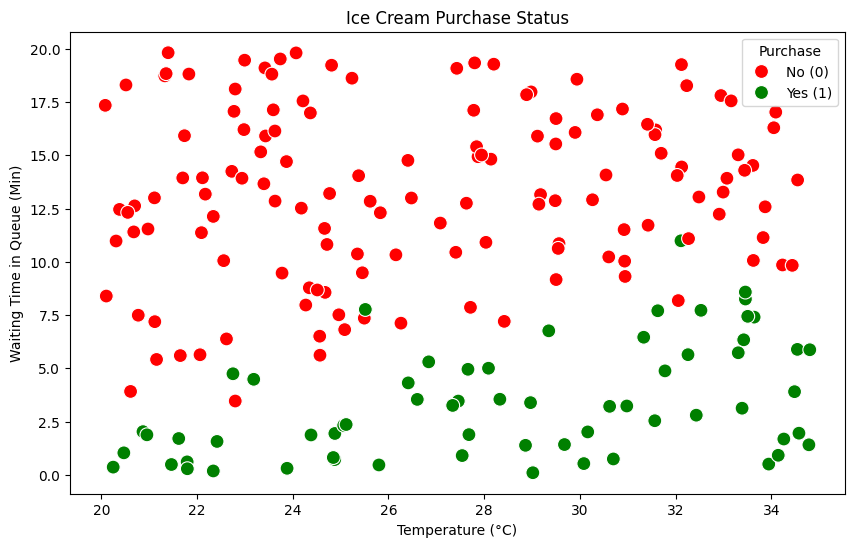

In [2]:
plt.figure(figsize=(10, 6))  # Make a wide plot
ax = sns.scatterplot(x='Temperature', y='Waiting_Time', hue='Purchase', data=df_class, palette=['red', 'green'], s=100)  # Plot points colored by buy/no-buy
plt.title('Ice Cream Purchase Status')  # Add title
plt.xlabel('Temperature (°C)')  # Label x-axis
plt.ylabel('Waiting Time in Queue (Min)')  # Label y-axis
handles, _ = ax.get_legend_handles_labels()  # Grab legend handles
plt.legend(handles, ['No (0)', 'Yes (1)'], title='Purchase')  # Rename legend labels for clarity
plt.show()  # Display the scatter plot

In [3]:
X = df_class[['Temperature', 'Waiting_Time']]  # Inputs: temperature and wait time
y = df_class['Purchase']  # Output: buy or not

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # Split data into train and test

# Logistic Regression Model
log_model = LogisticRegression()  # Create yes/no prediction model
log_model.fit(X_train, y_train)  # Train it on the training data

print("Classification Model Trained.")  # Confirm training finished

Classification Model Trained.


Model Accuracy: %97.50


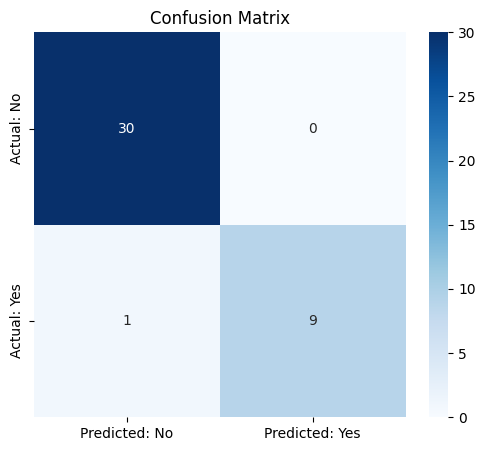

In [4]:
# Predictions
y_pred = log_model.predict(X_test)  # Ask model to guess buy/no-buy for test data

# 1. Accuracy Score (How often did it get it right?)
acc = accuracy_score(y_test, y_pred)  # Percentage of correct guesses
print(f"Model Accuracy: %{acc * 100:.2f}")  # Show accuracy

# 2. Confusion Matrix (Detailed Analysis)
cm = confusion_matrix(y_test, y_pred)  # Table of correct/incorrect counts

plt.figure(figsize=(6, 5))  # Make a small heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted: No', 'Predicted: Yes'], yticklabels=['Actual: No', 'Actual: Yes'])  # Visualize counts
plt.title('Confusion Matrix')  # Add title
plt.show()  # Display heatmap

In [5]:
# Example Customer: Temperature is 30 degrees and waiting time in queue is 15 minutes.
new_customer = [[30, 15]]  # Input shaped like training data

predicted_class = log_model.predict(new_customer)  # Model's yes/no guess
predicted_probability = log_model.predict_proba(new_customer)  # Probabilities for each class
print(f"Predicted Class: {predicted_class[0]} (0=No, 1=Yes)")  # Show class
print(f"Probability of No: %{predicted_probability[0][0] * 100:.1f}")  # Chance it says No
print(f"Probability of Yes:   %{predicted_probability[0][1] * 100:.1f}")  # Chance it says Yes

Predicted Class: 0 (0=No, 1=Yes)
Probability of No: %100.0
Probability of Yes:   %0.0


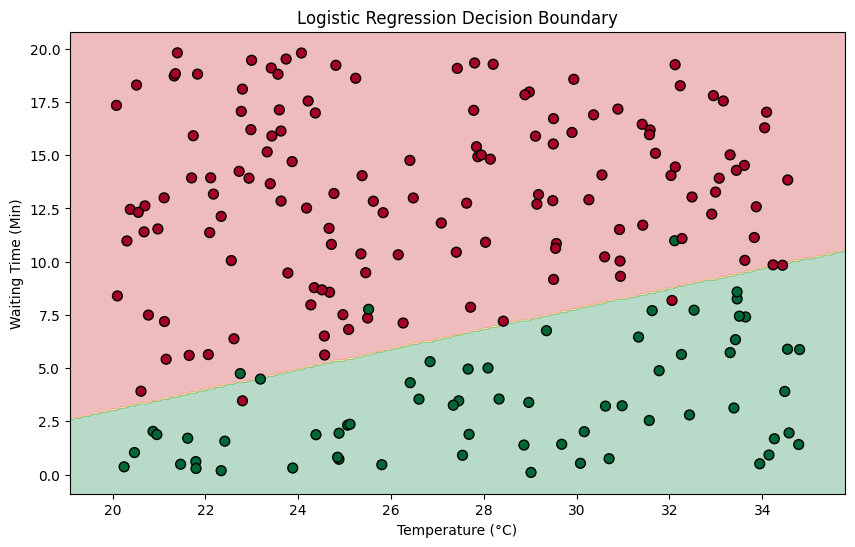

In [6]:
# to Visualize, set the boundaries
x_min, x_max = X['Temperature'].min() - 1, X['Temperature'].max() + 1  # Range for temperature axis
y_min, y_max = X['Waiting_Time'].min() - 1, X['Waiting_Time'].max() + 1  # Range for waiting time axis
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),  # Create grid of x values
                     np.arange(y_min, y_max, 0.1))  # Create grid of y values

# Predict for all grid points
Z = log_model.predict(np.c_[xx.ravel(), yy.ravel()])  # Predict class for every point in grid
Z = Z.reshape(xx.shape)  # Reshape back to grid form

# Plot the graph
plt.figure(figsize=(10, 6))  # Make wide plot
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn') # Background colors (Red/Green regions)
plt.scatter(X['Temperature'], X['Waiting_Time'], c=y, edgecolors='k', cmap='RdYlGn', s=50) # Points
plt.title('Logistic Regression Decision Boundary')  # Title
plt.xlabel('Temperature (°C)')  # Label x-axis
plt.ylabel('Waiting Time (Min)')  # Label y-axis
plt.show()  # Display plot